## Downloading with CDSE

In [1]:
# install with
# !pip install terragon-downloader[cdse]

In [1]:
import terragon
import geopandas as gpd
import xarray as xr
from utils import visualize_sat_images, list_of_dicts_to_tree
import rasterio

In [3]:
# we will use the sample data to download a minicube
# other datasets can be found here: https://dataspace.copernicus.eu/explore-data/data-collections
gdf = gpd.read_file("data/TUM_OTN.geojson")
gdf = gdf.to_crs("EPSG:32632")
arguments = dict(
    shp=gdf,
    collection="SENTINEL-2",
    start_date="2021-01-01",
    end_date="2021-01-05",
    bands=["B02", "B03", "B04"],
    resolution=10,
    download_folder="tests/download/",
    filter={
        "processingLevel": {"eq": "S2MSI2A"}  # we will use a filter to get only level 2 products
    },
)
gdf.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

credentials

In [4]:
# we use the s3 bucket to download the data: https://documentation.dataspace.copernicus.eu/APIs/S3.html
# credentials can be created here: https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials
credentials = {"aws_access_key_id": "<your-id>", "aws_secret_access_key": "<your-key>"}
tg = terragon.init("cdse", credentials=credentials)

Finding collections

In [ ]:
# explore the CDSE data on their website: https://dataspace.copernicus.eu/data-collections, https://browser.dataspace.copernicus.eu/
collections = tg.retrieve_collections(
    query={"id": "Sentinel.1.*"}, fields=["id", "title", "extent", "keywords"]
)  # filter field with regex and only return wished fields
list_of_dicts_to_tree(collections)

Tree(nodes=(Node(name='Item 1', nodes=(Node(name='id: SENTINEL-1-RTC'), Node(name='title: SENTINEL-1-RTC'), No…

download (with eodata AWS S3 backend)

In [6]:
# we can now download the data, in the background we search the folder of the corresponding tile for the correct files
# and use rasterio with its virtual files to open and clip the extend of the files directly,
# it is possible to download data with up to 4 concurrent workers per account, see here: https://documentation.dataspace.copernicus.eu/Quotas.html
# make sure to have the right packages installed (depending on the data you want to download), for example jp2 needs libgdal-jp2openjpeg and .nc needs libgdal-hdf5
ds = tg.create(**arguments, num_workers=4)
# or
# items = tg.search(**arguments, num_workers=4)
# ds = tg.download(items)
ds

<xarray.Dataset> Size: 6kB
Dimensions:      (x: 27, y: 18, time: 2)
Coordinates:
  * x            (x) float64 216B 6.976e+05 6.976e+05 ... 6.979e+05 6.979e+05
  * y            (y) float64 144B 5.326e+06 5.326e+06 ... 5.326e+06 5.326e+06
  * time         (time) datetime64[ns] 16B 2021-01-01T10:23:29.024000 2021-01...
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, y, x) uint16 2kB 65535 65535 65535 ... 65535 65535 65535
    B03          (time, y, x) uint16 2kB 65535 65535 65535 ... 65535 65535 65535
    B04          (time, y, x) uint16 2kB 65535 65535 65535 ... 65535 65535 65535
Attributes:
    crs:          EPSG:32632
    data_source:  CDSE
    collection:   SENTINEL-2

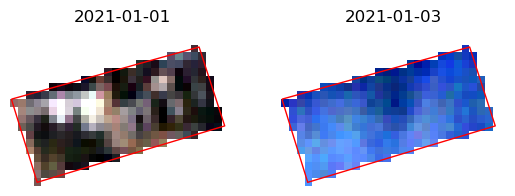

In [7]:
ds = ds.where(ds != 65535)  # remove no data values
visualize_sat_images(ds, gdf, list(reversed(arguments["bands"])))

### special arguments for cdse

In [8]:
# filter_asset_path: filtering asset paths with regex
# sometimes the same file names exists with a different folder path, for example for Sentinel-2 the image data is in the folder IMG_DATA
# defaults are already set for COP-DEM and Sentinel-2
ds = tg.create(**arguments, num_workers=4, filter_asset_path={"SENTINEL-2": ".*/IMG_DATA/.*"})

In [9]:
# use_virtual_rasterio_file: downloading the tile files instead of using the virtual rasterio file - default: bool = True
# in combination with rm_tmp_files=True, the tile files will be deleted after the download
ds = tg.create(**arguments, use_virtual_rasterio_file=False, rm_tmp_files=True)

In [10]:
# resampling: using a different resampling method in the reprojection process - default: rasterio.enums.Resampling = rasterio.enums.Resampling.nearest
ds = tg.create(**arguments, resampling=rasterio.enums.Resampling.bilinear)

### filtering meta data

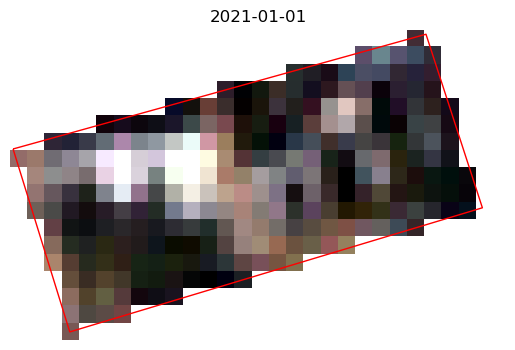

In [11]:
# it is also possible to filter for more meta data from the tiles,
# we match them with the meta data from the stac items: https://documentation.dataspace.copernicus.eu/APIs/STAC.html
# we support four types of filters: eq, ueq, lt, gt, in (equal, unequal, less than, greater than, python "in" with list)
# for example we can use this to filter for cloud cover:
arguments["filter"].update({"cloudCover": {"lt": 90}})
ds = tg.create(**arguments)
ds = ds.where(ds != 65535)  # remove no data values
visualize_sat_images(ds, gdf, list(reversed(arguments["bands"])))

### filtering items manually
some properties are hard to filter with the available filter options, hence you can use your own logic to filter them

here an example how you can filter them: some Sentinel-2 tiles are available in different processing baseline versions

In [12]:
import re
import pandas as pd


# function to filter for the highest Sentinel-2 processing baseline
def filter_doubled_processing_baseline_by_name(items):
    """use the name of the item to filter the processing highest baseline, except for the 99.99 fill value
    see https://sentinels.copernicus.eu/en/web/sentinel/user-guides/sentinel-2-msi/naming-convention
    """
    filtered_items = {}

    # re like "N0301" or "N0500"
    pattern = re.compile(r"(.*_N)(\d{4})(_.*)")

    for item in items:
        match = pattern.match(item["id"])
        if match:
            base_id = match.group(1) + match.group(3)
            proc_date = pd.to_datetime(base_id.split("_")[-1].split(".")[0])
            base_id = "_".join(base_id.split("_")[:-1])
            num = int(match.group(2))
            # If the base_id is not in the dictionary
            # or if the current num is larger (not when it is 99.99, which seems to be a fill value)
            # or if the num is the same but the processing date is newer
            # update the entry
            if (
                base_id not in filtered_items
                or (
                    filtered_items[base_id]["num"] < num < 9999
                    or filtered_items[base_id]["num"] == 9999 != num
                )
                or (
                    proc_date > filtered_items[base_id]["proc_date"]
                    and num == filtered_items[base_id]["num"]
                )
            ):
                filtered_items[base_id] = {
                    "item": item,
                    "num": num,
                    "proc_date": proc_date,
                }
        else:
            raise ValueError(f"Could not extract processing baseline from {item['id']}.")

    # Extract the filtered list
    result = [entry["item"] for entry in filtered_items.values()]

    return result

In [13]:
items = tg.search(num_workers=4, **arguments)
# filter the items by the highest processing baseline, but discard fill value 99.99 if possible
items = filter_doubled_processing_baseline_by_name(items)
tg.download(items)

<xarray.Dataset> Size: 3kB
Dimensions:      (x: 27, y: 18, time: 1)
Coordinates:
  * x            (x) float64 216B 6.976e+05 6.976e+05 ... 6.979e+05 6.979e+05
  * y            (y) float64 144B 5.326e+06 5.326e+06 ... 5.326e+06 5.326e+06
  * time         (time) datetime64[ns] 8B 2021-01-01T10:23:29.024000
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, y, x) uint16 972B 65535 65535 65535 ... 65535 65535
    B03          (time, y, x) uint16 972B 65535 65535 65535 ... 65535 65535
    B04          (time, y, x) uint16 972B 65535 65535 65535 ... 65535 65535
Attributes:
    crs:          EPSG:32632
    data_source:  CDSE
    collection:   SENTINEL-2

In [14]:
# some collection like, Sentinel-1 - IW_SLC__1S, have multiple files (if not filtered)
# if multiple files are found, the files will be added as separate bands, with the filename as data_var
from shapely.geometry import Polygon

gdf = gpd.GeoDataFrame(
    geometry=[
        Polygon(
            [
                (9.295, 47.425),
                (9.296, 47.425),
                (9.296, 47.426),
                (9.295, 47.426),
            ]
        )
    ],
    crs="EPSG:4326",
)
args = dict(
    shp=gdf,
    collection="SENTINEL-1",
    start_date="2022-01-01",
    end_date="2022-01-03",
    bands=["VV"],
    resolution=10,
    filter={"productType": {"eq": "IW_SLC__1S"}},
)
ds = tg.create(**args)
ds.data_vars

/mnt/datastorage/home/adrianhohl/Terragon/terragon/copernicus_data_space_ecosystem.py:417: UserWarning: No data found in bounds.
  warnings.warn("No data found in bounds.")
/mnt/datastorage/home/adrianhohl/Terragon/terragon/copernicus_data_space_ecosystem.py:206: UserWarning: Multiple files found for band VV: [PosixPath('Sentinel-1/SAR/SLC/2022/01/01/S1A_IW_SLC__1SDV_20220101T053510_20220101T053537_041263_04E777_7EED.SAFE/measurement/s1a-iw1-slc-vv-20220101t053512-20220101t053537-041263-04e777-004.tiff'), PosixPath('Sentinel-1/SAR/SLC/2022/01/01/S1A_IW_SLC__1SDV_20220101T053510_20220101T053537_041263_04E777_7EED.SAFE/measurement/s1a-iw2-slc-vv-20220101t053510-20220101t053535-041263-04e777-005.tiff'), PosixPath('Sentinel-1/SAR/SLC/2022/01/01/S1A_IW_SLC__1SDV_20220101T053510_20220101T053537_041263_04E777_7EED.SAFE/measurement/s1a-iw3-slc-vv-20220101t053511-20220101t053536-041263-04e777-006.tiff')].
Adding them as new bands.
  warnings.warn(f"Multiple files found for band {band}: {f_paths

Data variables:
    VV_s1a-iw1-slc-vv-20220101t053512-20220101t053537-041263-04e777-004_1  (time, y, x) complex64 616B ...
    VV_s1a-iw2-slc-vv-20220101t053510-20220101t053535-041263-04e777-005_1  (time, y, x) complex64 616B ...